# Climate Data Exploratory Data Analysis

## Introduction
This notebook contains an exploratory data analysis of climate data from 1900 to 2023. The dataset includes global temperatures, CO2 concentration, sea level rise, and Arctic ice area.

Your task is to perform a comprehensive EDA following the requirements in the README.md file.

In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

## 1. Data Preparation

Load the climate data and perform necessary cleaning and aggregation.

In [11]:
# Load the dataset
df = pd.read_csv(r'./data/Climate_Change_Indicators.csv') # Place the correct path to the file you are reading here (Make sure to load using the relative path)

# Display the first few rows of the dataset
df.head()

,Year,Global Average Temperature (°C),CO2 Concentration (ppm),Sea Level Rise (mm),Arctic Ice Area (million km²)
0,1948,13.17,397.04,116.25,5.97
1,1996,13.10,313.17,277.92,9.66
2,2015,14.67,311.95,290.32,8.40
3,1966,14.79,304.25,189.71,11.83
4,1992,13.15,354.52,14.84,11.23


In [13]:
# Check for missing values and basic information about the dataset
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 5 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Year                             1048576 non-null  int64  
 1   Global Average Temperature (°C)  1048576 non-null  float64
 2   CO2 Concentration (ppm)          1048576 non-null  float64
 3   Sea Level Rise (mm)              1048576 non-null  float64
 4   Arctic Ice Area (million km²)    1048576 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 40.0 MB
None

Missing Values:
Year                               0
Global Average Temperature (°C)    0
CO2 Concentration (ppm)            0
Sea Level Rise (mm)                0
Arctic Ice Area (million km²)      0
dtype: int64


In [40]:
# TODO: Aggregate data by year to create a 124-year time series
#aggregate_data = df.groupby('Year').agg(['mean'])
aggregate_data = df.groupby('Year').mean().reset_index()
# Display the first few rows of the aggregated dataset
print(aggregate_data.head(10))
# Now rename columns to keep the original names
#aggregate_data.columns = [col[0] for col in aggregate_data.columns]  # Flatten column names
#variables = ['Global Average Temperature (°C)', 'CO2 Concentration (ppm)','Sea Level Rise (mm)', 'Arctic Ice Area (million km²)']
#print(aggregate_data[variables].describe())




   Year  Global Average Temperature (°C)  CO2 Concentration (ppm)  \
0  1900                        14.506663               350.373405   
1  1901                        14.485343               349.757140   
2  1902                        14.476262               349.299686   
3  1903                        14.492360               349.644375   
4  1904                        14.494241               349.537032   
5  1905                        14.486222               349.768517   
6  1906                        14.501610               350.269288   
7  1907                        14.507352               349.707452   
8  1908                        14.489932               349.908538   
9  1909                        14.524320               349.477657   

   Sea Level Rise (mm)  Arctic Ice Area (million km²)  
0           150.408288                       8.978659  
1           150.548828                       8.947272  
2           152.174821                       9.035554  
3           150.

## 2. Univariate Analysis

Analyze each climate variable independently.

In [41]:
# TODO: Perform univariate analysis for each climate variable
# Include descriptive statistics and appropriate visualizations
# Your code here
# Rename columns for easier access
aggregate_data.rename(columns={
    "Global Average Temperature (°C)": "Temperature",
    "CO2 Concentration (ppm)": "CO2",
    "Sea Level Rise (mm)": "Sea_Level",
    "Arctic Ice Area (million km²)": "Ice_Area"
}, inplace=True)

# Set style
#sns.set_style("whitegrid")

# List of variables for analysis
variables = ["Temperature", "CO2", "Sea_Level", "Ice_Area"]

# Descriptive Statistics
for column in variables:
    print(f"Descriptive Statistics for {column}:")
    print(aggregate_data[column].describe().round(2))
    print(f"Mean: {aggregate_data[column].mean():.2f}")
    print(f"Median: {aggregate_data[column].median():.2f}")
    print(f"Standard Deviation: {aggregate_data[column].std():.2f}")
    print(f"Minimum: {aggregate_data[column].min():.2f}")
    print(f"Maximum: {aggregate_data[column].max():.2f}")
    print("\n")

 

Descriptive Statistics for Temperature:
count    124.00
mean      14.50
std        0.01
min       14.47
25%       14.49
50%       14.50
75%       14.50
max       14.53
Name: Temperature, dtype: float64
Mean: 14.50
Median: 14.50
Standard Deviation: 0.01
Minimum: 14.47
Maximum: 14.53


Descriptive Statistics for CO2:
count    124.00
mean     350.03
std        0.46
min      348.64
25%      349.69
50%      350.02
75%      350.37
max      351.00
Name: CO2, dtype: float64
Mean: 350.03
Median: 350.02
Standard Deviation: 0.46
Minimum: 348.64
Maximum: 351.00


Descriptive Statistics for Sea_Level:
count    124.00
mean     149.99
std        1.03
min      148.05
25%      149.21
50%      149.92
75%      150.56
max      152.67
Name: Sea_Level, dtype: float64
Mean: 149.99
Median: 149.92
Standard Deviation: 1.03
Minimum: 148.05
Maximum: 152.67


Descriptive Statistics for Ice_Area:
count    124.00
mean       9.00
std        0.04
min        8.89
25%        8.98
50%        9.00
75%        9.03
max     

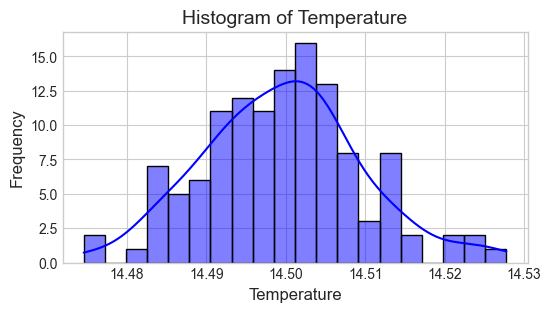

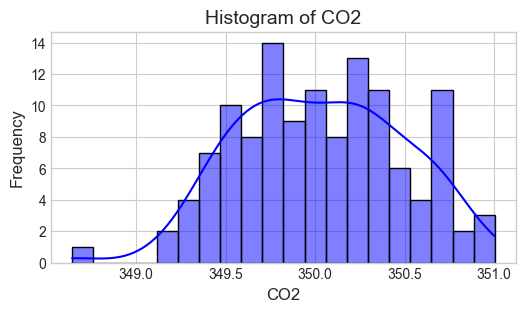

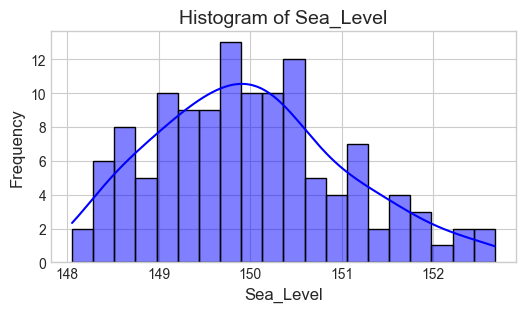

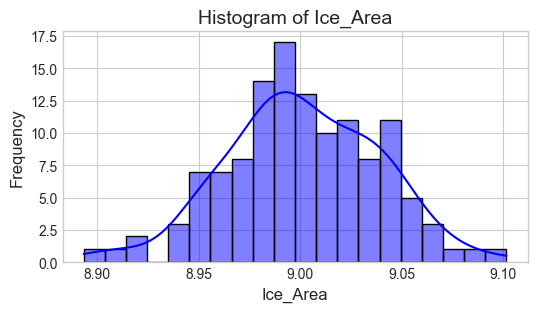

In [42]:
#Plot Histogram
for column in variables:
    plt.figure(figsize=(6, 3))
    sns.histplot(aggregate_data[column], bins=20, kde=True, color="blue")
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title(f"Histogram of {column}", fontsize=14)
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11456\3080815404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=aggregate_data[column], palette='viridis', whis=1.5)


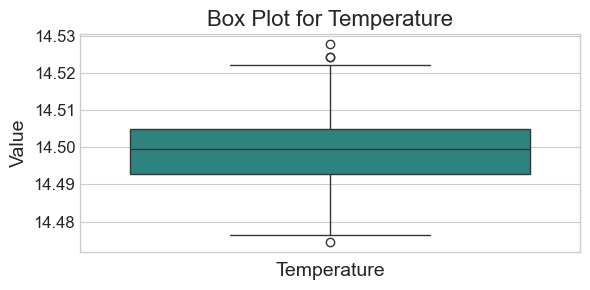

C:\Users\Admin\AppData\Local\Temp\ipykernel_11456\3080815404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=aggregate_data[column], palette='viridis', whis=1.5)


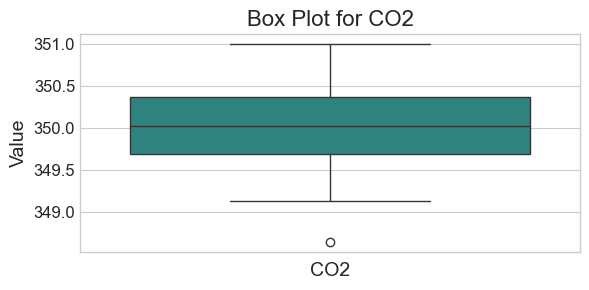

C:\Users\Admin\AppData\Local\Temp\ipykernel_11456\3080815404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=aggregate_data[column], palette='viridis', whis=1.5)


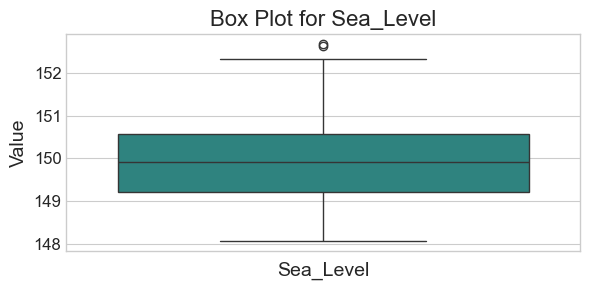

C:\Users\Admin\AppData\Local\Temp\ipykernel_11456\3080815404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=aggregate_data[column], palette='viridis', whis=1.5)


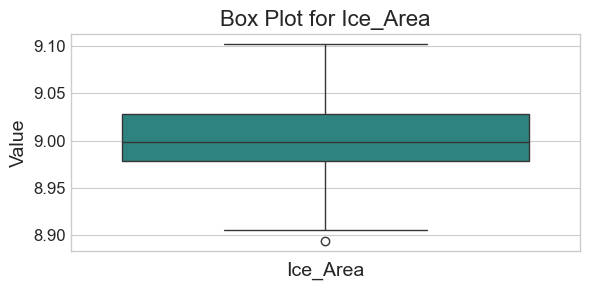

In [43]:
# Plot Boxplots
for column in variables:
    plt.figure(figsize=(6, 3))
    sns.boxplot(y=aggregate_data[column], palette='viridis', whis=1.5)
    plt.title(f'Box Plot for {column}', fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

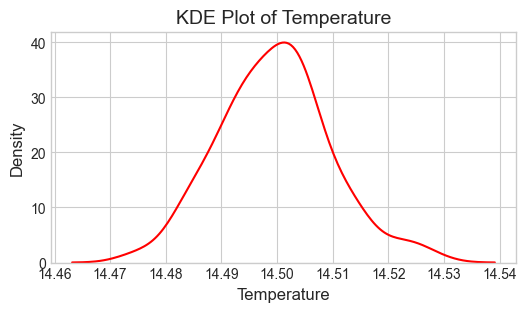

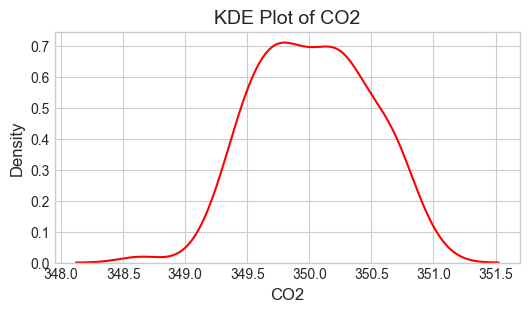

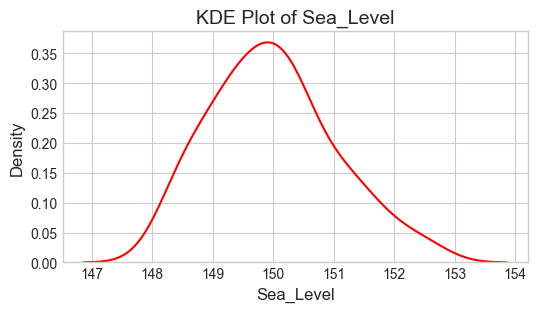

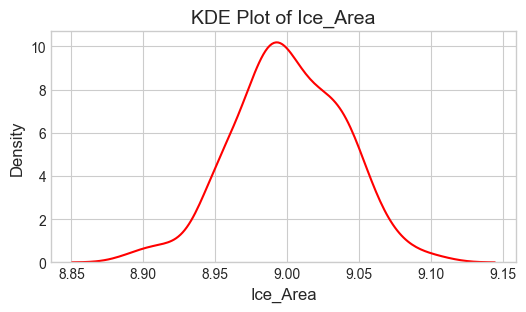

In [44]:
# Plot KDE plotss
for column in variables:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(aggregate_data[column], color='red')
    plt.title(f'KDE Plot of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.show()

<Figure size 600x300 with 0 Axes>

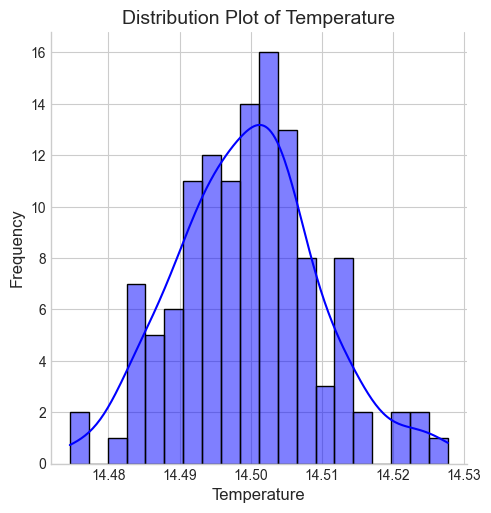

<Figure size 600x300 with 0 Axes>

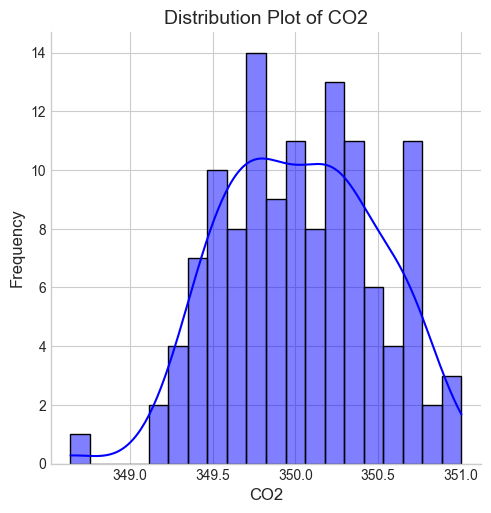

<Figure size 600x300 with 0 Axes>

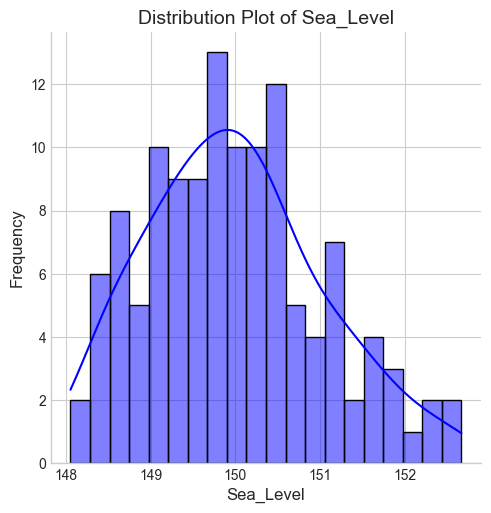

<Figure size 600x300 with 0 Axes>

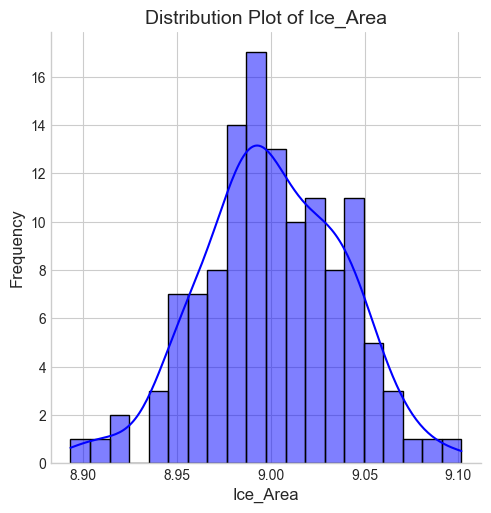

In [45]:

# Plot Distribution plots (displot)
for column in variables:
    plt.figure(figsize=(6, 3))
    sns.displot(aggregate_data[column], bins=20, kde=True, color="blue")
    plt.title(f'Distribution Plot of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

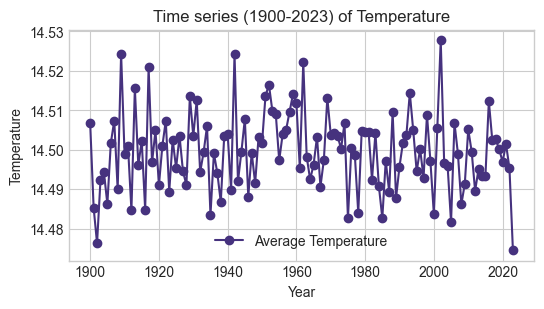

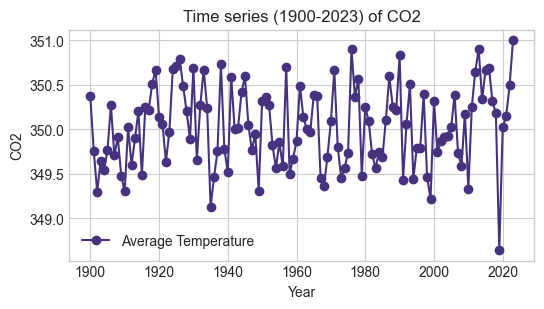

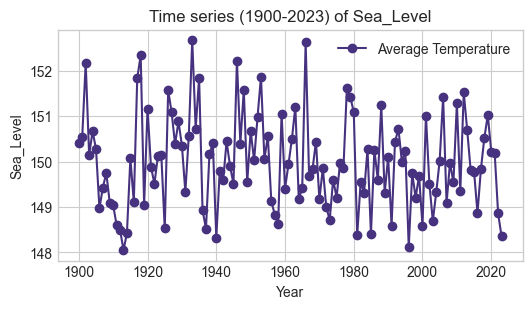

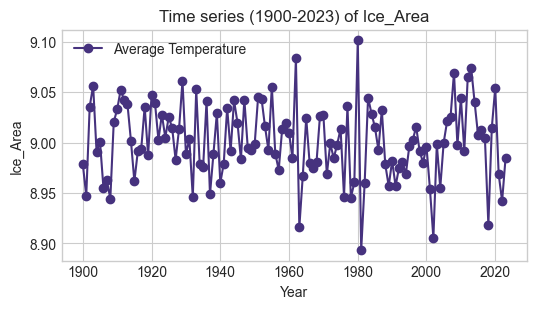

In [46]:
#Time series Analysis
for column in variables:
    plt.figure(figsize=(6, 3))
    plt.plot(aggregate_data["Year"], aggregate_data[column], marker='o', linestyle='-', label="Average Temperature")
    plt.xlabel("Year")
    plt.ylabel(column)
    plt.title(f"Time series (1900-2023) of {column}")
    plt.legend()
    plt.show() 

## 3. Bivariate Analysis

Explore relationships between pairs of climate variables.

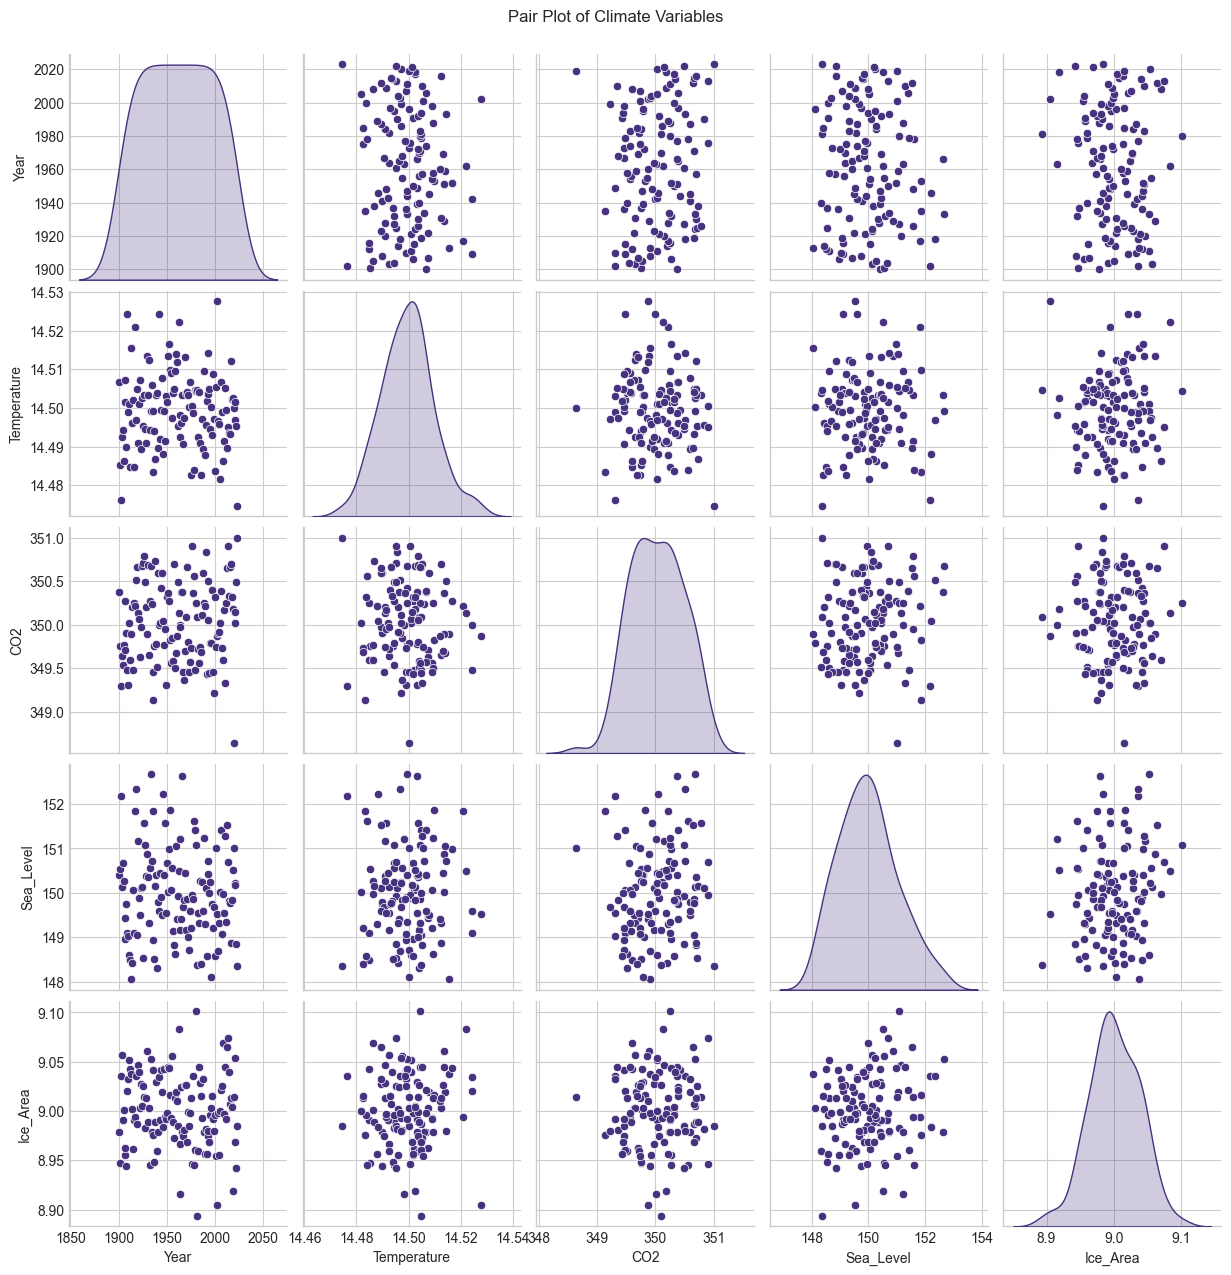

In [47]:
# TODO: Perform bivariate analysis
# Include correlation analysis and appropriate visualizations
# 1. Scatter plots for pairs of variables
sns.pairplot(aggregate_data, diag_kind='kde', markers='o')
plt.suptitle('Pair Plot of Climate Variables', y=1.02)
plt.show()

In [49]:
# 2. Compute correlation coefficients (excluding Year variable)
correlation_matrix = aggregate_data.drop(columns=['Year']).corr()
print("Correlation Coefficients:\n", correlation_matrix)

Correlation Coefficients:
              Temperature       CO2  Sea_Level  Ice_Area
Temperature     1.000000 -0.067980   0.003878  0.047027
CO2            -0.067980  1.000000   0.098212  0.009986
Sea_Level       0.003878  0.098212   1.000000  0.129528
Ice_Area        0.047027  0.009986   0.129528  1.000000


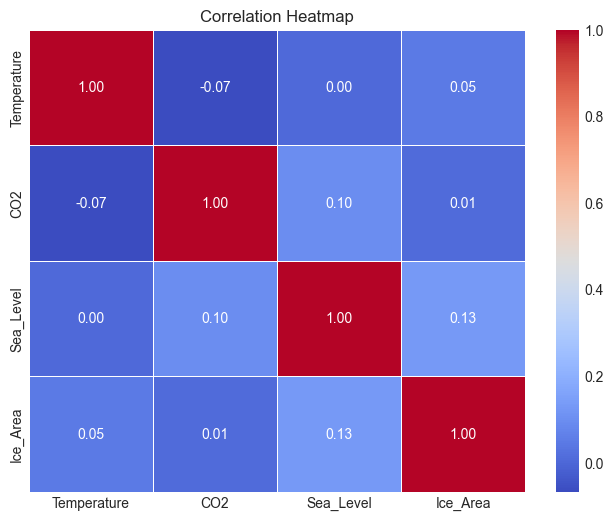

In [50]:
# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

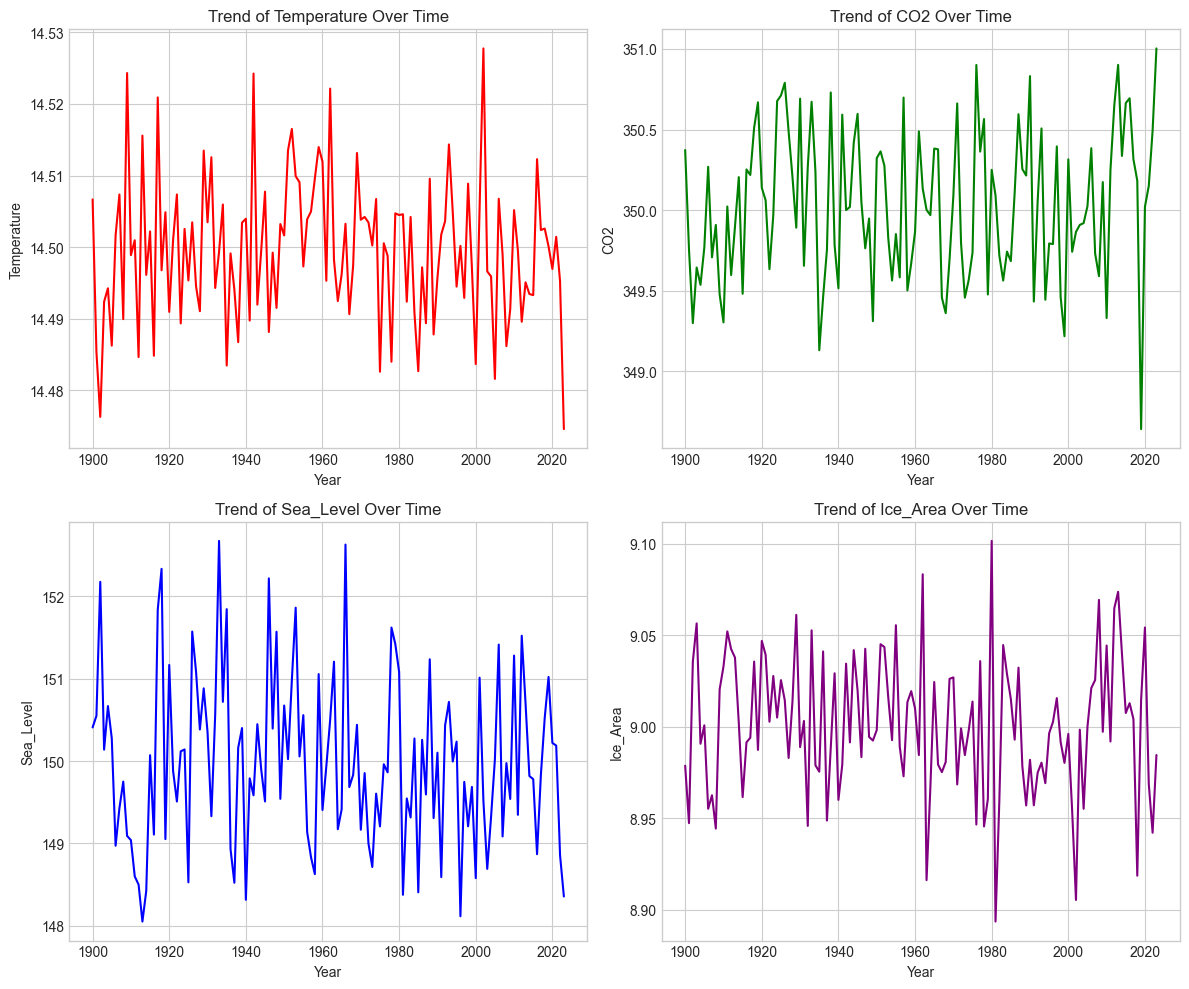

In [51]:
# 4. Line plots to analyze trends over time
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variables = ['Temperature', 'CO2', 'Sea_Level', 'Ice_Area']
colors = ['r', 'g', 'b', 'purple']

for ax, var, color in zip(axes.flatten(), variables, colors):
    sns.lineplot(data=aggregate_data, x='Year', y=var, ax=ax, color=color)
    ax.set_title(f'Trend of {var} Over Time')
    ax.set_xlabel('Year')
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

## 4. Multivariate Analysis

Investigate relationships among three or more variables.

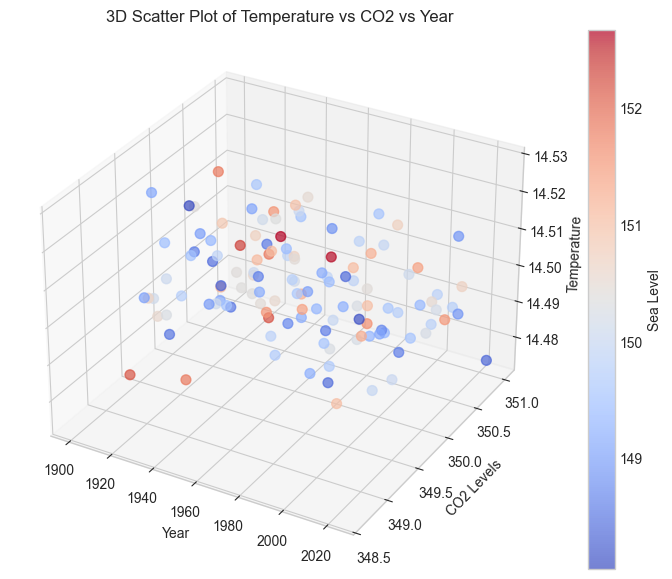

In [54]:
# TODO: Perform multivariate analysis
# Create advanced visualizations showing multiple variables
# Your code here
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D figure and subplot together
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": "3d"})

# Scatter plot
sc = ax.scatter(aggregate_data['Year'], aggregate_data['CO2'], aggregate_data['Temperature'], 
                c=aggregate_data['Sea_Level'], cmap='coolwarm', s=50, alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('CO2 Levels')
ax.set_zlabel('Temperature')
ax.set_title('3D Scatter Plot of Temperature vs CO2 vs Year')

# Color bar
cbar = plt.colorbar(sc)
cbar.set_label('Sea Level')

plt.show()

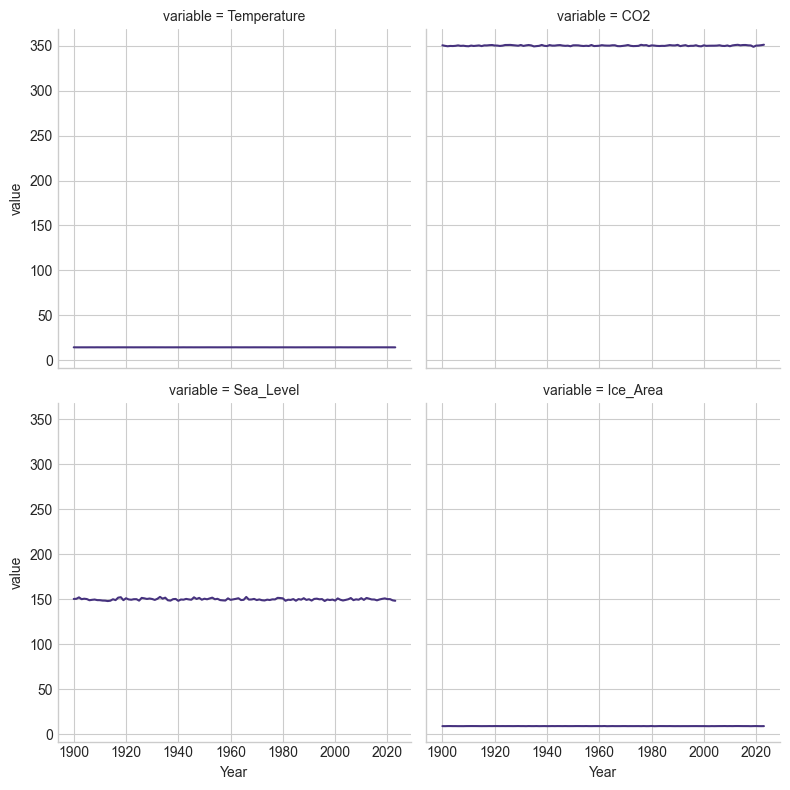

In [57]:
# Reshape data for Seaborn
df_melted = aggregate_data.melt(id_vars='Year', value_vars=['Temperature', 'CO2', 'Sea_Level', 'Ice_Area'])

# Create multiple line plots for each variable
g = sns.FacetGrid(df_melted, col='variable', col_wrap=2, height=4, sharex=True)
g.map(sns.lineplot, 'Year', 'value')

plt.show()

## 5. Conclusions and Insights

Summarize your findings and discuss their implications.

# TODO: Write your conclusions here